In [3]:
# ==========================================
# ANALISIS DATA PELANGGAN E-COMMERCE
# Menggunakan Random Forest Regressor
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ==========================================
# MEMBACA DATASET
# ==========================================

df = pd.read_csv("ecommerce_customer_satisfaction.csv")

print("===== 5 DATA PERTAMA =====")
print(df.head())

print("\n===== INFORMASI DATASET =====")
print(df.info())

# ==========================================
# MEMILIH FITUR DAN TARGET
# ==========================================

target = "customer_zip_code_prefix"

features = [
    "customer_city",
    "customer_state"
]

X = df[features].copy()
y = df[target]

# ==========================================
# ENCODING DATA KATEGORIK
# ==========================================

le_city = LabelEncoder()
le_state = LabelEncoder()

X["customer_city"] = le_city.fit_transform(
    X["customer_city"]
)

X["customer_state"] = le_state.fit_transform(
    X["customer_state"]
)

# ==========================================
# SPLIT DATA TRAINING DAN TESTING
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# MEMBANGUN MODEL RANDOM FOREST
# ==========================================

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# PREDIKSI
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# EVALUASI MODEL
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===== HASIL EVALUASI =====")
print("Mean Absolute Error :", round(mae, 3))
print("R2 Score :", round(r2, 3))

# ==========================================
# ANALISIS PENGARUH FAKTOR
# ==========================================

importance = model.feature_importances_

hasil = pd.DataFrame({
    "Faktor": features,
    "Pengaruh": importance
})

hasil = hasil.sort_values(
    by="Pengaruh",
    ascending=False
)

print("\n===== TINGKAT PENGARUH FAKTOR =====")
print(hasil)



===== 5 DATA PERTAMA =====
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

===== INFORMASI DATASET =====
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns)

## visualisasi

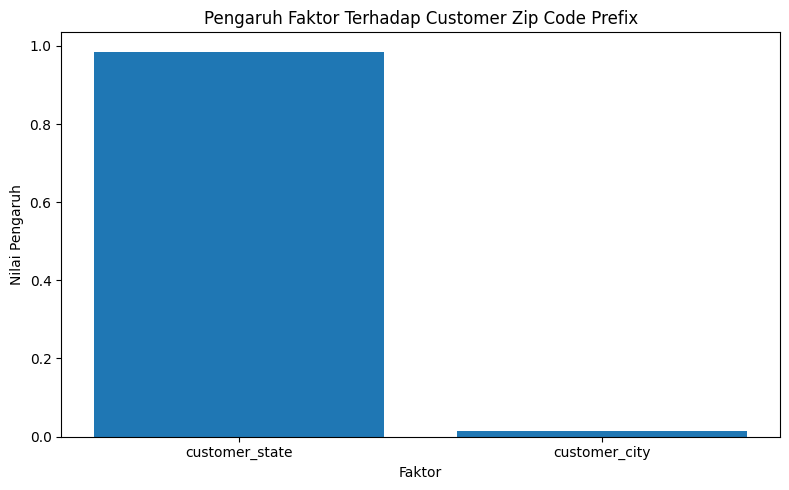

In [4]:
# ==========================================
# VISUALISASI
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    hasil["Faktor"],
    hasil["Pengaruh"]
)

plt.title(
    "Pengaruh Faktor Terhadap Customer Zip Code Prefix"
)

plt.xlabel("Faktor")
plt.ylabel("Nilai Pengaruh")

plt.tight_layout()
plt.show()